#Pair-wise transfer learning

This exercise demonstrates a transfer learning approach using the ALIGNN architecture. We will first pre-train an ALIGNN model on a dataset of formation energies. Subsequently, we will employ this pre-trained model as the initialization point for training a second ALIGNN model tasked with predicting the highest optical phonon mode frequency. This fine-tuning strategy will involve updating all model parameters during the training phase for the phonon mode frequency prediction task.

We will then compare the predictive performance of this fine-tuned model against that of a baseline ALIGNN model, which we shall refer to as the "SCRATCH" model, trained exclusively on the phonon mode frequency data. This comparison will highlight the potential benefits of leveraging pre-training for downstream property prediction.

This specific fine-tuning methodology, where all layers are retrained, is one of several possible strategies detailed in the relevant literature on transfer learning and is chosen here for illustrative purposes.

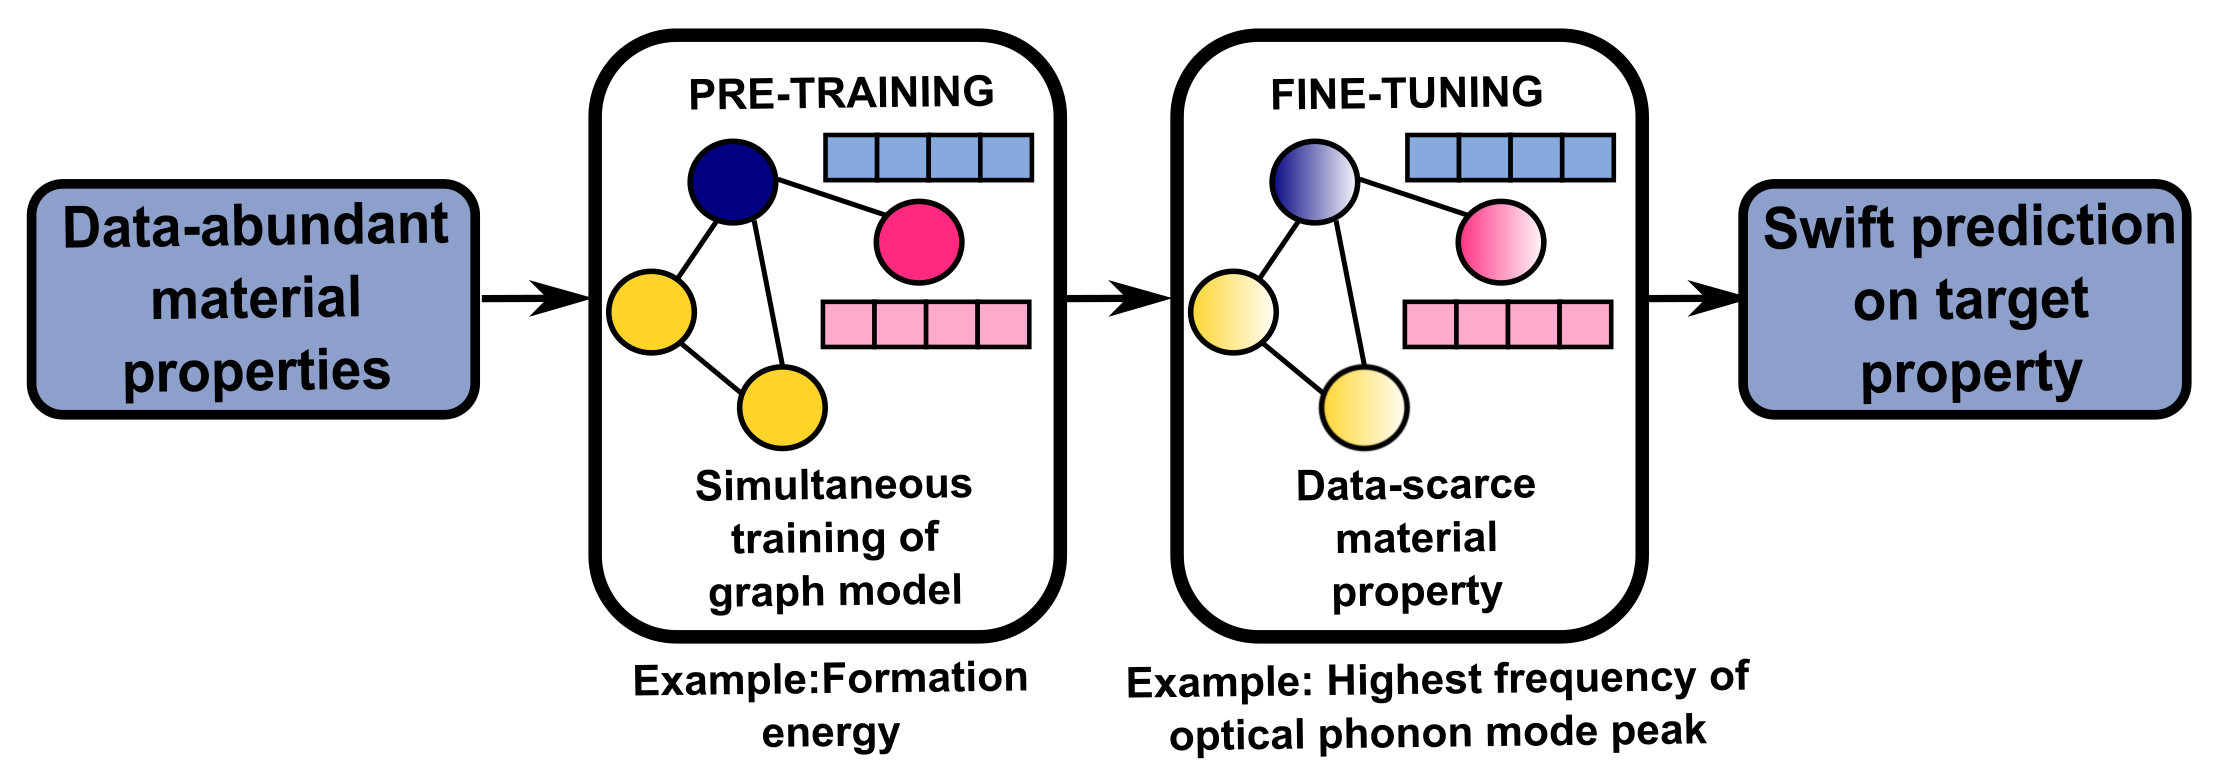

# Installation

Install ALIGNN with `pip` (under a minute). The versions are pinned so the
notebook keeps working as the libraries change.

In [ ]:
!pip install -q "alignn==2026.8.11" "jarvis-tools==2026.6.12"

In [ ]:
# Sanity check: confirm the stack imported cleanly before continuing.
import alignn, jarvis, torch, pandas
print("CUDA:", torch.cuda.is_available())

Confirm the versions and that the GPU is visible (Runtime > Change runtime type > T4 GPU).

# Loading and pre-processing the data


We use the highest optical phonon frequency (in cm$^{-1}$) from the MatBench
repository, and a model pre-trained on formation energy (in eV/atom).

## Download the data

This fetches two folders:

- `form_energy/`: the ALIGNN model pre-trained on formation energy
  (`current_model.pt`), plus the `config.json` that describes its architecture;
- `phonon_data/`: the phonon-frequency training and test sets
  (`train.pkl`, `test.pkl`).

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1I1XHUiabw1PJSHTm3wC1Nrxqv9PvGDTU?usp=sharing
!gdown --folder https://drive.google.com/drive/folders/1OaZp2CwYLCDsshQ-owWhF4woafpteBqh?usp=sharing

## Load the data

Each set is a pandas DataFrame with one row per material:

1. `jid`: an ID;
2. `target`: the highest optical phonon frequency, in cm$^{-1}$;
3. `atoms`: the crystal structure, in JARVIS `Atoms` format.

In [ ]:
import pandas as pd

df_train = pd.read_pickle("/content/phonon_data/train.pkl")
df_test = pd.read_pickle("/content/phonon_data/test.pkl")
print(len(df_train), "training and", len(df_test), "test structures")
df_train.head()

## Standardize and Normalize the data

It is good practice to scale the target values before training. The same recipe
works for any property from any materials data repository.


<details>
<summary>More details:</summary>

1. The data is already split into a training set and a test set (90:10), and a
   few extreme outliers have been removed.

2. **Standardize** the targets with scikit-learn's
   [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html):

   $$z = \frac{x - \mu}{\sigma}$$

   where $x$ is a target value, and $\mu$ and $\sigma$ are the mean and the
   standard deviation of the training targets.

3. **Normalize** the standardized values to the range $[a, b] = [-1, 1]$:

   $$z_{\text{norm}} = a + \frac{(z - z_{\min})\,(b - a)}{z_{\max} - z_{\min}}$$

   where $z_{\min}$ and $z_{\max}$ are the smallest and the largest standardized
   training targets.

4. Choose a small random subset of `N_TRAIN` training structures to train on.

**Use only the training-set statistics ($\mu$, $\sigma$, $z_{\min}$, $z_{\max}$)
to scale both the training and the test set.**

</details>

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Step 1: standardize, z = (x - mean) / std.  Step 2: rescale to [-1, 1].
# Both steps learn their numbers from the TRAINING data only.
scaler = make_pipeline(StandardScaler(), MinMaxScaler(feature_range=(-1, 1)))
norm_train = scaler.fit_transform(df_train[["target"]]).flatten()
norm_test = scaler.transform(df_test[["target"]]).flatten()

## Visualize the data

Visualize the distributions before and after standardization and normalization

In [ ]:
import matplotlib.pyplot as plt
# Create the figure and axes for the subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # 1 row, 2 columns of subplots.

# Plot the first histogram
axes[0].hist(df_train['target'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Not Standardized and Normalized')
axes[0].set_xlabel('Highest optical mode phonon frequency')
axes[0].set_ylabel('Frequency')

# Plot the second histogram
axes[1].hist(norm_train, bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title('Standardized and Normalized')
axes[1].set_xlabel('Highest optical mode phonon frequency')
axes[1].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# One dict per structure, with the scaled target (the DataFrames keep cm^-1)
train = df_train.assign(target=norm_train).to_dict(orient="records")
test = df_test.assign(target=norm_test).to_dict(orient="records")

## Create dataset for training

We train on a small random subset of `N_TRAIN` structures.

(ALIGNN splits these 80/10/10 internally: 80% to train on, 10% to monitor
training and 10% for a quick internal test. Our real test is the separate test
set.)

In [ ]:
import random

SEED = 0         # fixes which structures are picked, the data split and the initial weights
N_TRAIN = 100    # number of training structures

random.seed(SEED)
train_subset = [train[i] for i in random.sample(range(len(train)), N_TRAIN)]
print("number of training structures:", len(train_subset))

In [ ]:
from jarvis.core.atoms import Atoms
import os
output_dir = "./phonons/data"
os.makedirs(output_dir, exist_ok=True) # create data dir if does not exist
output_file_name="id_prop.csv"
with open(output_file_name, 'w') as f:
    for i in train_subset:
        atoms = Atoms.from_dict(i["atoms"])
        jid = i["jid"]
        poscar_name = os.path.join(output_dir, "POSCAR-" + str(jid) + ".vasp") # path to poscar
        target = i['target']
        atoms.write_poscar(poscar_name)
        f.write("%s,%6f\n" % (poscar_name, target))

# Create a configuration file

Save a configuration file contains all parameters required for defining the model architecture and training process. We will use the `alignn_atomwise_pure` model (the pure-PyTorch version of ALIGNN) for making graph level prediction. Note that alignn_atomwise can make both graph and atom level predictions.

<details>
<summary>More Details:</summary>


``version:`` A string representing the version of the code or data being used. It's useful for tracking changes and reproducibility.

``dataset:`` A string indicating the name of the dataset you're using.

``target:`` The name of the column in your dataset that contains the target property you want to predict.

``atom_features:`` Specifies how the atom features are generated. "cgcnn" typically means using features similar to those used in the CGCNN model.

``neighbor_strategy:`` The method for finding neighboring atoms in the crystal structure. "pure_torch" connects each atom to its neighbours within `cutoff` (at most `max_neighbors` of them), and forms bond angles between bonds shorter than `three_body_cutoff`.

``id_tag:`` A string that represents the ID for each sample in the dataset.

``dtype:`` Specifies the data type used for calculations during the training process. float32 is the standard.

``random_seed:`` An integer that ensures reproducibility by initializing the random number generator with this number.

``classification_threshold:`` If this is a classification problem, it is the threshold above which the results will be labeled as 1.

``n_val, n_test, n_train:`` Specifies the exact number of training, test and validation samples if they are required and different from splitting with train_ratio, val_ratio and test_ratio.

``train_ratio:`` The ratio of data to use for training.

``val_ratio:`` The ratio of data to use for validation.

``test_ratio:`` The ratio of data to use for testing. Note that these three values need to sum to less than or equal to 1.

``target_multiplication_factor:`` A factor to multiply the target property with.

``epochs:`` The number of times the model iterates through the entire training dataset.

``batch_size:`` The number of samples used for one update step of the training.

``weight_decay:`` A regularization technique that adds a small penalty to the model weights during training to prevent overfitting.

``learning_rate:`` The parameter that controls how much the weights are updated during optimization.

``filename:`` The base name for output files (e.g., model checkpoints, predictions).

``warmup_steps:`` The number of steps to linearly increase the learning rate during the initial phase of training.

``criterion:`` The loss function used to calculate the error during training ("mse" is mean squared error).

``optimizer:`` The optimization algorithm used to update the model's weights ("adamw" is a common one).

``scheduler:`` The learning rate scheduler which changes the learning rate as the training progresses.

``pin_memory:`` Whether to load data into pinned memory (faster data loading with GPUs).

``save_dataloader:`` Whether to save the dataloader for restarting a run.

``write_checkpoint:`` Whether to save the model's weights at various points during the training process.

``write_predictions:`` Whether to save the model's predictions on the validation/test sets.

``store_outputs:`` Whether to save the outputs of the model from the validation dataset.

``progress:`` Whether to show a progress bar during training.

``log_tensorboard:`` Whether to log training progress in TensorBoard (a visualization tool).

``standard_scalar_and_pca:`` Whether to apply standard scaling and PCA for pre-processing.

``use_canonize:`` Whether to canonize or permute the structure to a common representation.

``num_workers:`` How many threads to use when loading the data.

``output_dir:`` The directory where all output files are saved.

``use_lmdb:`` Whether to load data from a memory-mapped LMDB database for faster loading.

``normalize_graph_level_loss:`` Whether to normalize graph level losses by the number of atoms or not.

``distributed:`` Whether to use distributed training with multiple GPUs and nodes.

``data_parallel:`` Whether to use data parallelism with multiple GPUs.

``n_early_stopping:`` Number of epochs without improvement in the validation loss before early stopping occurs.

``cutoff:`` Defines the radius cutoff for defining the neighbor lists in angstroms.

``cutoff_extra:`` Extra radius above which a cutoff function can be used if required.

``max_neighbors:`` The maximum number of neighbors to consider for each atom.

``keep_data_order:`` Whether to keep the same order of data in the dataset or randomly shuffle it.

``name:`` Specifies the model to use (alignn_atomwise is a custom model from the previous files).

``alignn_layers:`` The number of ALIGNN layers in the model (the number of alternating crystal and line graph update layers).

``gcn_layers:`` The number of gated graph convolution layers (GCN) to use on the crystal graph.

``atom_input_features:`` The number of features representing each atom in the input.

``edge_input_features:`` The size of the feature vector to use for edge features (bond lengths in our case).

``triplet_input_features:`` The size of the feature vector to use for angle features in the line graph.

``embedding_features:`` The dimension to which the edge and angle features are embedded before the main ALIGNN interaction layers.

``hidden_features:`` The size of the hidden layers within the ALIGNN and GCN layers.

``output_features:`` The number of output features for the graph level prediction.

``grad_multiplier:`` A multiplier applied to gradients. Usually -1 to make gradients become forces based on energy.

``calculate_gradient:`` Whether to calculate gradients (forces) for force prediction.

``atomwise_output_features:`` The number of output features for atom-level predictions.

``graphwise_weight:`` The weight applied to the graph-level loss.

``gradwise_weight:`` The weight applied to the force loss.

``stresswise_weight:`` The weight applied to the stress loss.

``atomwise_weight:`` The weight applied to the per-atom loss.

``link:`` The link function applied to the final output.

``zero_inflated:`` Whether to use zero-inflated loss for sparse data.

``classification:`` Whether this is a classification (not regression) problem.

``force_mult_natoms:`` Multiply the gradient force by the number of atoms.

``energy_mult_natoms:`` Multiply the energy prediction by the number of atoms

``include_pos_deriv:`` Whether to compute derivatives with respect to the positions directly.

``use_cutoff_function:`` Whether to apply a cutoff function to edge interactions based on the bond length.

``inner_cutoff:`` The inner cutoff radius for the cutoff function in angstrom.

``stress_multiplier:`` A multiplier applied to the stress tensor calculation.

``add_reverse_forces:`` Whether to add the reverse force when calculating the total force.

``lg_on_fly:`` If true, the line graph is constructed in the forward function rather than precomputed and saved.

``batch_stress:`` Whether to perform stress calculation as a single batch instead of one by one.

``multiply_cutoff:`` Whether to multiply the edge features with the cutoff function or just use the cutoff for the edge distances.

``use_penalty:`` Whether to add a bondlength penalty to the total loss function.

``extra_features:`` An optional extra feature for each graph.

``exponent:`` The exponent used for calculating the cutoff function.

``penalty_factor:`` The factor by which the bondlength penalty is applied.

``penalty_threshold:`` The bond length below which penalty is applied.

``additional_output_features:`` If we want to predict any other additional output feature in addition to the graph level property, then this should be set to a value greater than zero.

``additional_output_weight:`` This parameter specifies the weight that needs to be applied to the additional_output_features.

</details>



In [ ]:
import json
config = {
    "version": "112bbedebdaecf59fb18e11c929080fb2f358246",
    "dataset": "user_data",
    "target": "target",
    "atom_features": "cgcnn",
    "neighbor_strategy": "pure_torch",
    "id_tag": "jid",
    "dtype": "float32",
    "random_seed": SEED,
    "classification_threshold": None,
    "n_val": None,
    "n_test": None,
    "n_train": None,
    "train_ratio": 0.8,
    "val_ratio": 0.1,
    "test_ratio": 0.1,
    "target_multiplication_factor": None,
    "epochs": 30,
    "batch_size": 2,
    "weight_decay": 1e-05,
    "learning_rate": 0.001,
    "filename": "A",
    "warmup_steps": 2000,
    "criterion": "mse",
    "optimizer": "adamw",
    "scheduler": "onecycle",
    "pin_memory": False,
    "save_dataloader": False,
    "write_checkpoint": True,
    "write_predictions": True,
    "store_outputs": True,
    "progress": True,
    "log_tensorboard": False,
    "standard_scalar_and_pca": False,
    "use_canonize": True,
    "num_workers": 0,
    "cutoff": 8.0,
    "cutoff_extra": 3.0,
    "max_neighbors": 12,
    "three_body_cutoff": 8.0,
    "keep_data_order": True,
    "normalize_graph_level_loss": False,
    "distributed": False,
    "data_parallel": False,
    "n_early_stopping": None,
    "output_dir": "temp",
    "use_lmdb": True,
    "model": {
        "name": "alignn_atomwise_pure",
        "alignn_layers": 4,
        "gcn_layers": 4,
        "atom_input_features": 92,
        "edge_input_features": 80,
        "triplet_input_features": 40,
        "embedding_features": 64,
        "hidden_features": 64,
        "output_features": 1,
        "grad_multiplier": -1,
        "calculate_gradient": False,
        "atomwise_output_features": 0,
        "graphwise_weight": 1.0,
        "gradwise_weight": 1.0,
        "stresswise_weight": 0.0,
        "atomwise_weight": 0.0,
        "link": "identity",
        "zero_inflated": False,
        "classification": False,
        "force_mult_natoms": False,
        "energy_mult_natoms": False,
        "include_pos_deriv": False,
        "use_cutoff_function": False,
        "inner_cutoff": 3.0,
        "stress_multiplier": 1.0,
        "add_reverse_forces": True,
        "lg_on_fly": True,
        "batch_stress": True,
        "multiply_cutoff": False,
        "use_penalty": True,
        "extra_features": 0,
        "exponent": 5,
        "penalty_factor": 0.1,
        "penalty_threshold": 1.0
    }
}

file_path = "config.json"

with open(file_path, "w") as json_file:
    json.dump(config, json_file)

# How ALIGNN works

ALIGNN (Atomistic Line Graph Neural Network;
[Choudhary & DeCost, *npj Comput. Mater.* 7, 185 (2021)](https://doi.org/10.1038/s41524-021-00650-1))
turns a crystal into two graphs and learns from both:

- **Atom graph.** Every atom is a node, described by 92 element features (CGCNN).
  Every pair of atoms closer than 8 Å is an edge (at most 12 neighbours per
  atom), described by its bond length.
- **Line graph.** Every *bond* is a node, and two bonds that share an atom are
  connected. That connection is described by the **bond angle** between them,
  which is the information that a plain atom graph lacks.
- **ALIGNN layers (4).** Each layer passes messages on the atom graph (updating
  atoms and bonds) and then on the line graph (updating bonds and angles).
  So bond-angle information flows into the atom features.
- **GCN layers (4).** A few more rounds of message passing on the atom graph only.
- **Output.** The atom features are averaged over the whole crystal and a final
  linear layer turns them into **one number**, the predicted property.

For **fine-tuning** we build exactly the same network, but start from the weights
of a model already trained on formation energy instead of random weights.
Then we train all layers on the phonon data.

# Train a model from scratch

We now construct a model from scratch for predicting the highest optical phonon mode frequency of the materials.
The config.json file contains all the required parameters for load and training the alignn_atomwise model.

Training the SCRATCH model

In [ ]:
%%time
!train_alignn.py --root_dir "./" --config "config.json" --output_dir=phonons --epochs 30

# Fine-tune a model using a model pre-trained on formation energy dataset

Now we load a pre-trained model on formation energy and then fine-tune it on the phonons dataset.
We will compare the predictions made by the fine-tuned model and the model constructed from scratch for the highest optical phonon mode predictions.
<details>
<summary>More Details:</summary>

Loading a pre-trained model on formation energy and fine-tuning on the phonon dataset. Note the pre-trained model checkpoint was obtained by training on 1000 formation energy datapoints for 500 epochs. The above code for constructing the scratch model with the respective data and `--epochs 500` can be used to generate the checkpoint.

`--restart_model_path` points at `current_model.pt`; `train_alignn.py` reads the architecture from the `config.json` in the same folder.

</details>

In [ ]:
%%time
!train_alignn.py --root_dir "./" --config "config.json" --output_dir=fine-tune --restart_model_path='/content/form_energy/current_model.pt' --epochs 30

# Test the scratch and fine-tuned model

We will now test both the scratch and the fine-tuned model on the prediction accuracy

In [ ]:
import json, torch, numpy as np, pandas as pd
from jarvis.core.atoms import Atoms
from alignn.graphs import Graph
from alignn.models.alignn_atomwise_pure import (
    ALIGNNAtomWisePure, ALIGNNAtomWisePureConfig)

device = "cuda" if torch.cuda.is_available() else "cpu"

def load_run(run_dir):
    """Rebuild a model from the config that training actually used."""
    cfg = json.load(open(f"{run_dir}/config.json"))
    m = ALIGNNAtomWisePure(ALIGNNAtomWisePureConfig(**cfg["model"]))
    # The model after the final epoch. The validation set is only 10% of
    # N_TRAIN, so picking the "best" epoch by validation loss would be luck.
    m.load_state_dict(torch.load(f"{run_dir}/last_model.pt", map_location=device))
    return m.eval().to(device), cfg

model_scratch, cfg = load_run("phonons")
model_ft, _ = load_run("fine-tune")

def predict(model, atoms, cfg):
    # Graph settings MUST match the ones training used, or the weights are
    # being applied to a different graph than they were fitted on.
    g, lg = Graph.atom_dgl_multigraph(
        atoms,
        neighbor_strategy=cfg["neighbor_strategy"],      # "pure_torch"
        cutoff=float(cfg["cutoff"]),
        max_neighbors=cfg["max_neighbors"],
        atom_features=cfg["atom_features"],
        use_canonize=cfg["use_canonize"],
        cutoff_extra=cfg["cutoff_extra"],
        three_body_cutoff=cfg["three_body_cutoff"],
        compute_line_graph=True,
        dtype=cfg["dtype"],
    )
    lat = [atoms.lattice.a, atoms.lattice.b, atoms.lattice.c]
    out = model([g.to(device), lg.to(device), lat])["out"]
    return out.detach().cpu().numpy().flatten().tolist()[0]

results_scratch, results_ft = [], []
for i in test:
    atoms = Atoms.from_dict(i["atoms"])
    results_scratch.append({"jid": i["jid"], "out_data": predict(model_scratch, atoms, cfg),
                            "target": i["target"]})
    results_ft.append({"jid": i["jid"], "out_data": predict(model_ft, atoms, cfg),
                       "target": i["target"]})

csv_scratch = pd.DataFrame(results_scratch)
csv_ft = pd.DataFrame(results_ft)
print(f"predicted {len(csv_scratch)} test structures with both models")
csv_scratch.head()

## Analyze the performance metrics

The models predict scaled values in [-1, 1]. `scaler.inverse_transform` undoes
both scaling steps (in reverse order) to get back to cm$^{-1}$, and then we score
both models on the same held-out test structures.

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

def to_cm(values):
    """Undo the scaling: from [-1, 1] back to cm^-1."""
    return scaler.inverse_transform(np.array(values).reshape(-1, 1)).flatten()

target = to_cm(csv_scratch["target"])
for name, csv in (("Scratch", csv_scratch), ("Fine-tuned", csv_ft)):
    pred = to_cm(csv["out_data"])
    print(f"{name:10s}  R2 = {r2_score(target, pred):.3f}   "
          f"MAE = {mean_absolute_error(target, pred):.1f} cm^-1")

### What to take away

- Both models saw exactly the same training structures, settings and number of
  epochs. The **only** difference is where the weights started.
- The fine-tuned model is more accurate (higher $R^2$, lower MAE). Its layers
  already learned how to describe atoms, bonds and angles while predicting
  formation energy, so the small phonon dataset only has to teach it the new
  property.

# Exercise: when does pre-training help?

Does fine-tuning always beat training from scratch? Test it by changing the
amount of training data.

Go back to **Create dataset for training**, change `N_TRAIN`, then re-run that
cell and every cell below it (run the cell, then *Runtime > Run after*). Write
down both models' $R^2$ and MAE each time.

1. **More data.** Set `N_TRAIN = 400` (training takes about 4 times longer).
   Does the fine-tuned model still beat the scratch model? By how much?
2. **Less data.** Set `N_TRAIN = 50`. How big is the gap now?

| `N_TRAIN` | Scratch $R^2$ | Fine-tuned $R^2$ | Scratch MAE | Fine-tuned MAE |
|---|---|---|---|---|
| 50  | | | | |
| 100 | | | | |
| 400 | | | | |

What does this tell you about when fine-tuning is worth it?

